In [88]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [89]:
df = pd.read_csv('Planets_dataset.csv', header=27)

In [90]:
def log_errs(val, errs, err_lower=None):
    err_lower = errs if err_lower is None else np.abs(err_lower)
    upper = np.log10(val+errs)
    mask = (val - errs <= 0)
    lower = np.log10(val-err_lower)
    lower[mask] = -np.inf
    logerr = 0.5*(upper-lower)
    return logerr

In [91]:
x = np.log10(df['pl_rade'].values)
y = np.log10(df['pl_masse'].values)
xerr = log_errs(df['pl_rade'].values, df['pl_radeerr1'].values, df['pl_radeerr2'].values)
yerr = log_errs(df['pl_masse'].values, df['pl_masseerr1'].values, df['pl_masseerr2'].values)

xmask = ~np.isinf(xerr)
ymask = ~(np.isinf(yerr) | np.isnan(yerr))
mask = xmask & ymask

/tmp/ipykernel_186944/2343081272.py:5: RuntimeWarning: invalid value encountered in log10
  lower = np.log10(val-err_lower)
/tmp/ipykernel_186944/2343081272.py:5: RuntimeWarning: divide by zero encountered in log10
  lower = np.log10(val-err_lower)


<ErrorbarContainer object of 3 artists>

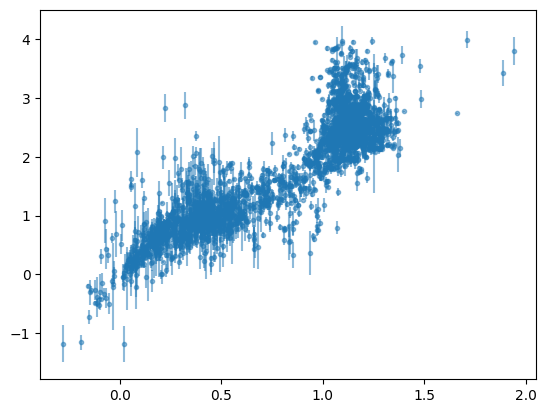

In [92]:
plt.errorbar(x[mask], y[mask], yerr=yerr[mask], fmt='o', alpha=0.5, ms=3)

In [93]:
N = int(np.sum(ymask))
X = x[ymask].reshape(-1,1)
y = y[ymask].reshape(-1,1)
yerr = yerr[ymask].reshape(-1,1)

In [94]:
def kernel(a, b, l=1, sigm_f=2):
    sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
    return sigm_f**2 * np.exp(-.5 * (1/l**2) * sqdist)

In [27]:
def posterior(X, y, yerr, l=1, sigm_f=1, Xtest=None):
    loc_kernel = lambda a, b: kernel(a, b, l, sigm_f)

    #Cholesky decomposition is used instead of directly inverting the the matrix
    K = loc_kernel(X, X)
    L = np.linalg.cholesky(K + (yerr**2).flatten()*np.eye(N))

    # points we're going to make predictions at.
    if Xtest is None:
        n=50
        Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)
    else:
        n = len(Xtest)
        Xtest = Xtest.reshape(-1,1)

    # mean at our test points.
    Lk = np.linalg.solve(L, loc_kernel(X, Xtest))
    mu = np.dot(Lk.T, np.linalg.solve(L, y))

    # variance at our test points.
    K_ = loc_kernel(Xtest, Xtest)
    s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
    s = np.sqrt(s2)

    # #draw samples from the posterior distribution
    S2 = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
    f_post = mu.reshape(-1,1) + np.dot(S2, np.random.normal(size=(n,5)))

    # f_post = np.random.normal(mu, s, size=(n,5))
    return f_post, Xtest

In [28]:
def posterior_3k(X, y, yerr, l=[100,200,300], sigm_f=[1,2,3], Xtest=None):
    loc_kernel = lambda a, b: kernel(a, b, l[0], sigm_f[0]) + kernel(a, b, l[1], sigm_f[1]) + kernel(a, b, l[2], sigm_f[2])

    #Cholesky decomposition is used instead of directly inverting the the matrix
    K = loc_kernel(X, X)
    L = np.linalg.cholesky(K + (yerr**2).flatten()*np.eye(N))

    # points we're going to make predictions at.
    if Xtest is None:
        n=50
        Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)
    else:
        n = len(Xtest)
        Xtest = Xtest.reshape(-1,1)

    # mean at our test points.
    Lk = np.linalg.solve(L, loc_kernel(X, Xtest))
    mu = np.dot(Lk.T, np.linalg.solve(L, y))

    # variance at our test points.
    K_ = loc_kernel(Xtest, Xtest)
    s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
    s = np.sqrt(s2)

    # #draw samples from the posterior distribution
    L = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
    f_post = mu.reshape(-1,1) + np.dot(L, np.random.normal(size=(n,5)))

    # f_post = np.random.normal(mu, s, size=(n,5))
    return f_post, Xtest

In [29]:
# f_post_3k = posterior_3k(X, y, yerr, l=[100,200,300], sigm_f=[1,2,3])
f_post, Xtest = posterior(X, y, yerr, l=1, sigm_f=2)

In [33]:
plt.scatter(X, y, alpha=0.5, s=3)
plt.plot(Xtest, f_post, 'r-', label='posterior')

In [14]:
l = np.geomspace(0.01, 100, 5)
sigm_f = np.geomspace(0.01, 100, 5)

posteriors_oneK = []

for i, l_ in enumerate(l):
    posteriors_oneK.append([])
    for j, sigm_f_ in enumerate(sigm_f):
        f_post, Xtest = posterior(X, y, yerr, l=l_, sigm_f=sigm_f_)
        posteriors_oneK[i].append(f_post)

In [50]:
fg, ax = plt.subplots(len(l), len(sigm_f), figsize=(15,17))

for i, l_ in enumerate(l):
    for j, sigm_f_ in enumerate(sigm_f):
        ax[i,j].scatter(X, y, alpha=0.5, s=3)
        ax[i,j].plot(Xtest, posteriors_oneK[i][j], 'r-', alpha=0.5)
        ax[i,j].set_title(f'l={l_}, sigm_f={sigm_f_}')

In [58]:
lm = [0.1,1,10]
sigm_fm = np.geomspace(0.1, 10, 3)

In [54]:
posteriors_3k = []

for i in range(3):
    posteriors_3k.append([])
    for j in range(3):
        posteriors_3k[i].append([])
        for k in range(3):
            f_post, Xtest = posterior_3k(X, y, yerr, lm, sigm_fm[[i,j,k]])
            posteriors_3k[i][j].append(f_post)

array([[ 0.08963049,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07239694,  0.00603298,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.05723588,  0.00998115,  0.002159  , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.0129246 ,  0.01094469, -0.00599275, ...,  0.00180862,
         0.        ,  0.        ],
       [ 0.01329519,  0.01502568, -0.00631404, ...,  0.00212105,
         0.00180566,  0.        ],
       [ 0.01331362,  0.01965211, -0.00651037, ...,  0.00330528,
         0.00211257,  0.00180354]], shape=(50, 50))

In [52]:
# fig, ax = plt.subplots(9, 3, figsize=(10,30))

for i in range(3):
    posteriors_3k.append([])
    fig, ax = plt.subplots(3, 3, figsize=(12,12))
    for j in range(3):
        posteriors_3k[i].append([])
        for k in range(3):
            f_post = posteriors_3k[i][j][k]
            ax[j,k].scatter(X, y, alpha=0.5, s=3)
            ax[j,k].plot(Xtest, f_post, 'r-', alpha=0.5)
            ax[j,k].set_title(f'sigm_f={sigm_fm[[i,j,k]]}')

array([8.03262545e-03, 5.27671394e-03, 3.37923051e-03, 2.11196192e-03,
       1.29354146e-03, 7.84063395e-04, 4.79122912e-04, 3.03687731e-04,
       2.06150062e-04, 1.52835763e-04, 1.23168461e-04, 1.05606813e-04,
       9.43989314e-05, 8.71340681e-05, 8.30213418e-05, 8.17902502e-05,
       8.30882029e-05, 8.62450777e-05, 9.02815917e-05, 9.40540542e-05,
       9.64495298e-05, 9.65693102e-05, 9.38620528e-05, 8.81888050e-05,
       7.98190502e-05, 6.93693597e-05, 5.77045055e-05, 4.58258304e-05,
       3.47745577e-05, 2.55798893e-05, 1.92843777e-05, 1.70829645e-05,
       2.06174594e-05, 3.24746649e-05, 5.69427637e-05, 1.01085353e-04,
       1.76193701e-04, 2.99673389e-04, 4.97409630e-04, 8.06635025e-04,
       1.27929360e-03, 1.98585639e-03, 3.01949774e-03, 4.50049095e-03,
       6.58062980e-03, 9.44743414e-03, 1.33278562e-02, 1.84911762e-02,
       2.52507643e-02, 3.39643928e-02])

In [84]:
def posterior(X, y, yerr, l=1, sigm_f=1, Xtest=None):
    loc_kernel = lambda a, b: kernel(a, b, l, sigm_f)

    #Cholesky decomposition is used instead of directly inverting the the matrix
    K = loc_kernel(X, X)
    L = np.linalg.cholesky(K + yerr.flatten()*np.eye(N))

    # points we're going to make predictions at.
    if Xtest is None:
        n=50
        Xtest = np.linspace(X.min(), X.max(), n).reshape(-1,1)
    else:
        n = len(Xtest)
        Xtest = Xtest.reshape(-1,1)

    # mean at our test points.
    Lk = np.linalg.solve(L, loc_kernel(X, Xtest))
    mu = np.dot(Lk.T, np.linalg.solve(L, y))

    # variance at our test points.
    K_ = loc_kernel(Xtest, Xtest)
    s2 = np.diag(K_) - np.sum(Lk**2, axis=0)
    s = np.sqrt(s2)

    # #draw samples from the posterior distribution
    S2 = np.linalg.cholesky(K_ + 1e-6*np.eye(n) - np.dot(Lk.T, Lk))
    f_post = mu.reshape(-1,1) + np.dot(S2, np.random.normal(size=(n,5)))

    # f_post = np.random.normal(mu, s, size=(n,5))
    return f_post

In [85]:
# f_post_3k = posterior_3k(X, y, yerr, l=[100,200,300], sigm_f=[1,2,3])
f_post = posterior(X, y, yerr, l=1, sigm_f=2)

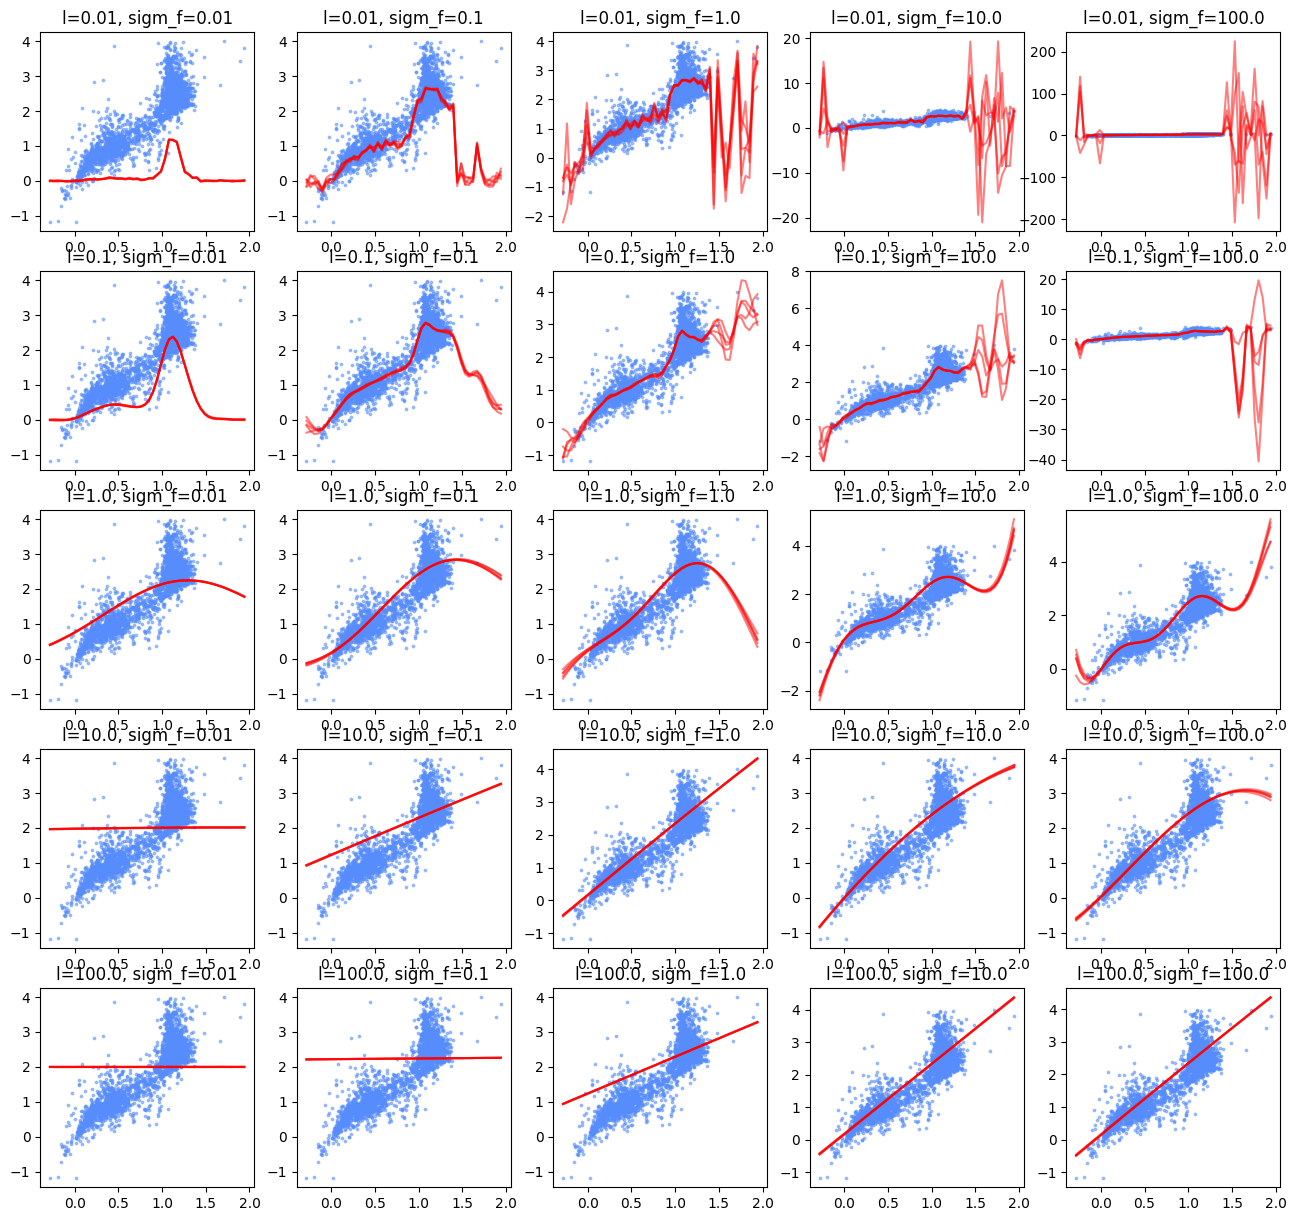

In [66]:
l = np.geomspace(0.01, 100, 5)
sigm_f = np.geomspace(0.01, 100, 5)

fg, ax = plt.subplots(len(l), len(sigm_f), figsize=(16,15))

for i, l_ in enumerate(l):
    for j, sigm_f_ in enumerate(sigm_f):
        f_post = posterior(X, y, yerr, l=l_, sigm_f=sigm_f_)
        ax[i,j].scatter(X, y, alpha=0.5, s=3)
        ax[i,j].plot(Xtest, f_post, 'r-', alpha=0.5)
        ax[i,j].set_title(f'l={l_}, sigm_f={sigm_f_}')

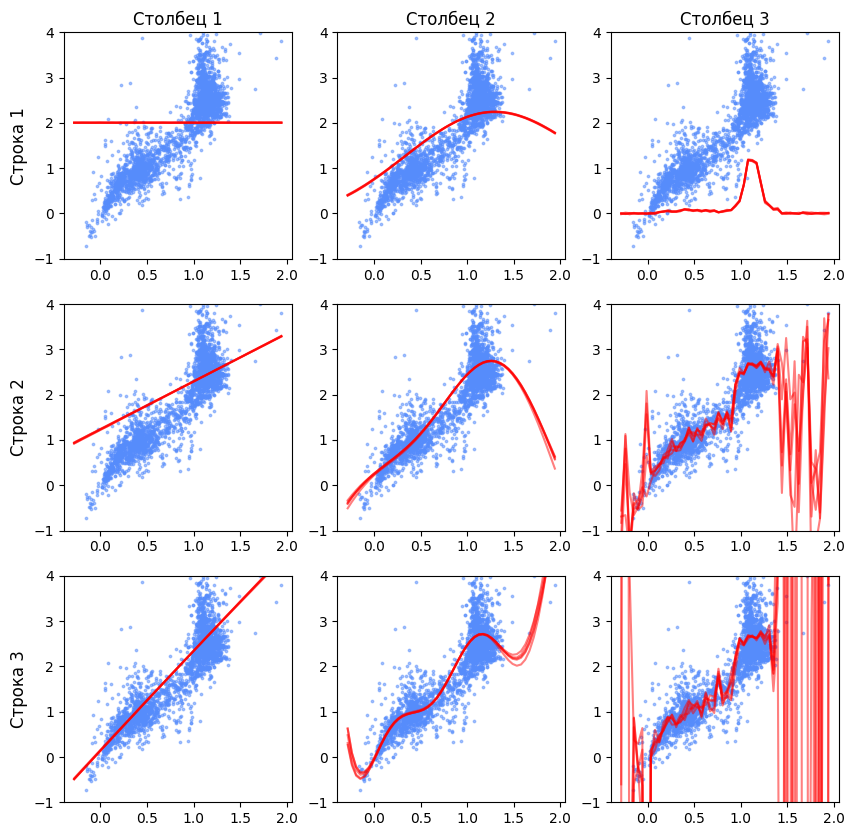

In [60]:
fg, ax = plt.subplots(len(l), len(sigm_f), figsize=(10,10))

for i, l_ in enumerate(l):
    posteriors.append([])
    for j, sigm_f_ in enumerate(sigm_f):
        ax[j,i].scatter(X, y, alpha=0.5, s=3)
        ax[j,i].plot(Xtest, posteriors[i][j], 'r-', alpha=0.5)
        ax[j,i].set_ylim(-1,4)

cols = ['Столбец {}'.format(col) for col in range(1, 4)]
rows = ['Строка {}'.format(row) for row in range(1, 4)]

# Рисуем что-нибудь и добавляем подписи
for ax_, col in zip(ax[0], cols):
    ax_.set_title(col)

for ax_, row in zip(ax[:,0], rows):
    ax_.set_ylabel(row, rotation=90, size='large')

In [69]:
posteriors_3k = []

for i in range(3):
    posteriors_3k.append([])
    for j in range(3):
        posteriors_3k[i].append([])
        for k in range(3):
            f_post = posterior_3k(X, y, yerr, lm, sigm_fm[[i,j,k]])
            posteriors_3k[i][j].append(f_post)

In [9]:
class our_kernel_fit():
    def __init__(self, X, y, sigm_f=1, l=1, n_samples=50, n_runs=5):
        self.X = X
        self.y = y
        self.sigm_f = sigm_f
        self.l = l
        self.n_samples = n_samples
        self.n_runs = n_runs

        self.set_kernel = lambda a, b: self.kernel(a, b, l, sigm_f)

        self.K = self.kernel(X, X, l, sigm_f) #N*N
        self.L = np.linalg.cholesky(self.K + 1e-6*np.eye(len(X))) #N*N

        self.Xtest = np.linspace(X.min(), X.max(), n_samples).reshape(-1,1) #n_samples*1

        self.Lk = np.linalg.solve(self.L, self.kernel(X, self.Xtest, l, sigm_f))
        self.mu = np.dot(self.Lk.T, np.linalg.solve(self.L, y))
        self.K_ = self.kernel(self.Xtest, self.Xtest, l, sigm_f)
        self.s2 = np.diag(self.K_) - np.sum(self.Lk**2, axis=0)
        self.s = np.sqrt(self.s2)

        self.L_post = np.linalg.cholesky(self.K_ + 1e-6*np.eye(n_samples) - np.dot(self.Lk.T, self.Lk))
        self.f_post = self.mu.reshape(-1,1) + np.dot(self.L, np.random.normal(size=(n_samples,n_runs)))

    def kernel(self, a, b, l=1, sigm_f=1):
        sqdist = np.sum(a**2,1).reshape(-1,1) + np.sum(b**2,1) - 2*np.dot(a, b.T)
        return sigm_f**2 * np.exp(-.5 * (1/l**2) * sqdist)

    def predict(self, Xtest=None):
        if Xtest is None:
            return self.f_post
        self.Xtest = Xtest
        self.Lk = np.linalg.solve(self.L, self.kernel(X, Xtest, self.l, self.sigm_f))
        self.mu = np.dot(self.Lk.T, np.linalg.solve(self.L, y))
        self.K_ = self.kernel(Xtest, Xtest, self.l, self.sigm_f)
        self.s2 = np.diag(self.K_) - np.sum(self.Lk**2, axis=0)
        self.s = np.sqrt(self.s2)

        self.L_post = np.linalg.cholesky(self.K_ + 1e-6*np.eye(self.n_samples) - np.dot(self.Lk.T, self.Lk))
        self.f_post = self.mu.reshape(-1,1) + np.dot(self.L, np.random.normal(size=(self.n_samples,self.n_runs)))
        return self.f_post
